# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 03_EDA
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno se centra en comprender profundamente los datos mediante análisis estadístico y visualización. El EDA nos permite descubrir patrones, relaciones y características importantes en los datos.

**Propósito:** Obtener insights sobre los datos y preparar el terreno para la selección de características relevantes para el modelado.

**Tareas habituales:**
- Análisis univariante de variables
- Análisis de correlaciones
- Visualización de distribuciones
- Detección de patrones y tendencias
- Análisis de series temporales si aplica
- Identificación de relaciones entre variables
- Generación de hipótesis
- Documentación de insights importantes

**Cada sección debe tener**:
- La Pregunta que se realiza sobre los datos
- El código que genera las tablas o los gráficos donde encontramos la respuesta
- El código que da respuesta a dicha pregunta
- La interpretar del resultado
- Las conclusiones

# INFORMACION PREVIA

El objetivo de este trabajo es investigar cual es **precio futuro** de un producto en un mercado especifico, por ende podemos decir que nuestra variable objetivo es **Precio promedio por kilogramo***

#EN CASO QUE YA SE HALLA REALIZADO LA CLONACION

In [26]:
!rm -rf /content/proyecto_ciencia_datos

In [54]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import getpass
import seaborn as sns

#CARGAMOS EL GITHUB Y LA CARPETA QUE VAMOS A ESTUDIAR (trusted)

In [27]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 316, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 316 (delta 84), reused 41 (delta 35), pack-reused 206 (from 1)
Receiving objects: 100% (316/316), 322.71 MiB | 28.87 MiB/s, done.
Resolving deltas: 100% (173/173), done.
Updating files: 100% (57/57), done.


In [28]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# Análisis de Datos

#SE REALIZA EL LLAMADO AL ARCHIVO

In [29]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,Fecha,Grupo,Producto,Mercado,Departamento,Código departamento,Municipio,Código municipio,Precio promedio por kilogramo*,Circulación
0,2013-01-01,"tuberculos, raices y platanos",papa unica,"barranquilla, granabastos",atlantico,8,barranquilla,8001,435.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, granabastos",atlantico,8,barranquilla,8001,3067.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico ble ltda","bogota, d.c.",11,"bogota, d.c.",11001,2967.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
...,...,...,...,...,...,...,...,...,...,...
744437,2026-05-01,frutas,manzana royal gala importada,"bogota, d.c., corabastos","bogota, d.c.",11,"bogota, d.c.",11001,7653.0,si
744438,2026-05-01,frutas,manzana royal gala importada,"armenia, mercar",quindio,63,armenia,63001,8086.0,si
744439,2026-05-01,frutas,manzana royal gala importada,arauca (arauca),arauca,81,arauca,81001,9667.0,si
744440,2026-05-01,frutas,mango comun,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,3900.0,si


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744442 entries, 0 to 744441
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Fecha                           744442 non-null  datetime64[ns]
 1   Grupo                           744442 non-null  object        
 2   Producto                        744442 non-null  object        
 3   Mercado                         744442 non-null  object        
 4   Departamento                    744442 non-null  object        
 5   Código departamento             744442 non-null  int64         
 6   Municipio                       744442 non-null  object        
 7   Código municipio                744442 non-null  int64         
 8   Precio promedio por kilogramo*  744442 non-null  float64       
 9   Circulación                     744442 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
me

In [6]:
df.describe()

,Fecha,Código departamento,Código municipio,Precio promedio por kilogramo*
count,744442,744442.000000,744442.000000,744442.000000
mean,2019-08-13 04:38:41.588518912,40.842739,40821.201712,7320.910660
min,2013-01-01 00:00:00,5.000000,5001.000000,82.000000
25%,2016-05-01 00:00:00,13.000000,13001.000000,1570.000000
50%,2019-08-01 00:00:00,47.000000,47001.000000,3371.000000
75%,2022-12-01 00:00:00,68.000000,68679.000000,9404.000000
max,2026-05-01 00:00:00,85.000000,85440.000000,270556.000000
std,NaN,27.886835,28017.513979,11079.700387


In [7]:
df["Precio promedio por kilogramo*"].describe()

,Precio promedio por kilogramo*
count,744442.000000
mean,7320.910660
std,11079.700387
min,82.000000
25%,1570.000000
50%,3371.000000
75%,9404.000000
max,270556.000000


#ESTUDIO DE LAS VARIABLES

## ESTUDIO DE LA VARIABLE GRUPO

1. Presentar lo grupos y la cantidad de productos que presenta en el dataset, a travez del tiempo.

**¿Cuales son los grupos y cual es la cantidad de productos que presenta?**

In [8]:
df.groupby('Grupo')['Producto'].nunique().sort_values(ascending=False).reset_index(name='Cantidad_Productos')

,Grupo,Cantidad_Productos
0,frutas,91
1,verduras y hortalizas,72
2,carnes,47
3,procesados,46
4,"tuberculos, raices y platanos",42
5,pescados,41
6,granos y cereales,40
7,lacteos y huevos,14


Podemos observar que se va a trabajar con 8 grupos, el grupo que más productos ha presentado son las frutas y el que menor productos presento fueron los lacteos

2. Mostrar el producto que mas se comercializo por grupo en el actual año.

**¿Cual es el producto mas comercializado o que mas registros realizo por cada grupo en 2026?**

In [9]:
productoMayorFrecuencia2026 = (
    df[df["Fecha"].dt.year == 2026]
      .groupby(["Grupo", "Producto"])
      .size()
      .reset_index(name="Cantidad")
      .sort_values(["Grupo", "Cantidad"], ascending=[True, False])
      .groupby("Grupo", as_index=False)
      .first()
)
productoMayorFrecuencia2026

,Grupo,Producto,Cantidad
0,carnes,pechuga de pollo,150
1,frutas,tomate de arbol,225
2,granos y cereales,lenteja importada,180
3,lacteos y huevos,queso costeno,125
4,pescados,bocachico importado congelado,80
5,procesados,harina de trigo,170
6,"tuberculos, raices y platanos",papa criolla limpia,215
7,verduras y hortalizas,pimenton,215


Podemos observar los productos que mas se comercializan por grupo para este año, podemos ver que aunque en la anterior los lacteos marcaban de ultimos, aqui no lo son, suben una posición, tambien que las frutas siguen manteniendo la corona de los grupos y de los productos por grupo, observemos el tomate de arbol se encontro registrado **225** veces en todos los mercados de Colombia

Ahora se puede ver el producto más costoso (por promedio) por cada grupo en el actual 2026

**El producto mas frecuente, puede es el más costoso (en promedio), o cual es?**

In [10]:
productoCaroDelGrupo2026 = (
    df[df["Fecha"].dt.year == 2026]
      .groupby(['Grupo', 'Producto'])['Precio promedio por kilogramo*']
      .mean()
      .round(2)
      .reset_index(name='Precio_Promedio')
      .sort_values(['Grupo', 'Precio_Promedio'], ascending=[True, False])
      .groupby('Grupo')
      .head(1)
)
productoCaroDelGrupo2026

,Grupo,Producto,Precio_Promedio
27,carnes,"carne de res, lomo fino",48397.75
49,frutas,arandano,54162.60
137,granos y cereales,frijol bolon,14422.22
166,lacteos y huevos,leche en polvo,43442.58
190,pescados,langostino u12,71918.22
221,procesados,cafe instantaneo,197272.01
284,"tuberculos, raices y platanos",platano harton verde llanero,4898.80
294,verduras y hortalizas,ajo,7291.96


El promedio se realiza por que se puede presentar que un producto que presenta un precio muy pequeño tuvo un pico muy alto por una situacion alterna, nos econtramos que los procesados tiene el producto más caro del mercado que es el **cafe instantaneo**

**En raiz de eso podemos coger cualquier serie y graficarla, si tomamos la ultima grafica pertenenciente del producto mas costoso**

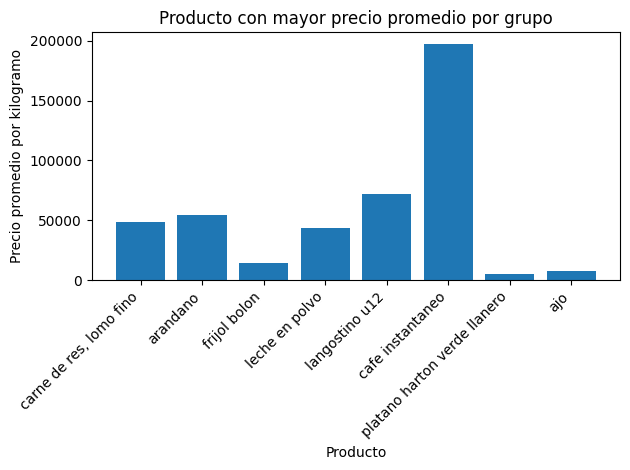

In [11]:
plt.bar(
    productoCaroDelGrupo2026['Producto'],
    productoCaroDelGrupo2026['Precio_Promedio']
)
plt.title('Producto con mayor precio promedio por grupo')
plt.xlabel('Producto')
plt.ylabel('Precio promedio por kilogramo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusión de estudio** La variable del grupo, tiene una alta relacion con la variable producto, aunque no va a ser utilizada para el modelo, es interesante que se pueda llegar a usar, el problema es el modelo puede usar otras variables para llegar más cerca a lo solicitado que es **predecir el precio futuro del producto**

## Estudio de la variable "Mercado"

Para iniciar veamos los mercados disponibles en el año 2026

**¿Cuales/Cuales son los mercados presentados en el 2026?**

In [19]:
mercados_2026 = (
    df.loc[df["Fecha"].dt.year == 2026, ["Mercado"]]
      .drop_duplicates()
      .dropna()
      .sort_values("Mercado")
      .reset_index(drop=True)
)
mercados_2026

,Mercado
0,"acacias, sociedad arrocera ltda."
1,"aguazul, agroindustrial molino sonora ap s.a.s"
2,"aguazul, arrocera la esmeralda s.a.s."
3,"alvarado, la guaira"
4,ancuya (narino)
...,...
133,"yopal, arroz barichara s.a.s."
134,"yopal, diana corporacion s.a.s"
135,"yopal, granos y cereales de colombia s. a."
136,"yopal, molinos casanare ltda."


El en año vigente nos encontramos con un total de 138 mercados disponibles en todo el país (Colombia)

Ahora, se quiere descubrir los mercados con la mayor cantidad de productos registados a nivel nacional

**¿Cuales son los mercados que presentan una mayor cantidad de productos registrados en el 2026?**

In [13]:
mercados_2026_prod = (
    df.loc[df["Fecha"].dt.year == 2026]
      .groupby('Mercado')['Producto'] \
      .nunique()\
      .sort_values(ascending=False)\
      .reset_index(name='Cantidad_Productos')
)
mercados_2026_prod

,Mercado,Cantidad_Productos
0,"medellin, central mayorista de antioquia",214
1,"bogota, d.c., corabastos",182
2,"cucuta, cenabastos",154
3,"villavicencio, cav",139
4,"cali, santa elena",134
...,...,...
133,nocaima (cundinamarca),2
134,"ayapel, molino santo tomas",1
135,"ayapel, molino ayapel",1
136,"sahagun, arrocera sahagun",1


Con esto se puede decir que los mercados (2026) que mas productos tradean o registran es la central mayorista ubicada en Medellín por que lleva una gran ventaja con el segundo, tambien hay mercados que solo cuenta con un producto es preocupante para el seguimiento del modelo si eso se sigue presentando durante los años pasados

El siguiente paso puede ser buscar el producto que mas se comercializa por cada mercado

**¿Cual es el producto que mas se comercializa o que mas registros presenta en la historia?**

In [18]:
productoFavoritoMercado = (
    df.groupby(['Mercado', 'Producto'])
      .size()
      .reset_index(name='Cantidad')
      .sort_values(['Mercado', 'Cantidad'], ascending=[True, False])
      .groupby('Mercado')
      .head(1)
)
productoFavoritoMercado

,Mercado,Producto,Cantidad
0,"acacias, sociedad arrocera ltda.",arroz blanco en bulto,1
4,"aguazul, agroindustrial molino sonora ap s.a.s",arroz blanco empacado,1
7,"aguazul, arrocera la esmeralda s.a.s.",arroz blanco empacado,1
11,"alvarado, la guaira",arroz blanco empacado,1
16,ancuya (narino),panela redonda morena,101
...,...,...,...
6801,"yopal, arroz barichara s.a.s.",arroz blanco empacado,1
6806,"yopal, diana corporacion s.a.s",arroz blanco empacado,1
6811,"yopal, granos y cereales de colombia s. a.",arroz blanco empacado,1
6816,"yopal, molinos casanare ltda.",arroz blanco empacado,1


Se encuentra con mercados que solo presentan 1 productos comercializado, algo que pueda afectar el modelo si ese producto presenta pocos registros por ende se tendria que implementar una regla para evitar que se presenten esos mercados con 1 solo producto y pocos mercados

Se podria mostrar en un mercado especifico

**Dado un mercado "x" ¿cual es el podrictp que mas se comercializa?**

In [21]:
mercadoSeleccionado = 'cali, santa elena'
ProductoEspecificoMercado = (
    df[df['Mercado'] == mercadoSeleccionado]['Producto']
      .value_counts()
)
ProductoEspecificoMercado.head(5)

,count
Producto,
"carne de cerdo, brazo sin hueso",161
"carne de cerdo, espinazo",161
"carne de cerdo, lomo sin hueso",161
"carne de cerdo, pernil sin hueso",161
"carne de res, bola de brazo",161


Esta es una funcion vital para el algortimo, pues se necesita fijar al mercado para realizar consultas de una manera mucho mas especifica, aqui encontramos que los productos que mas registros presentan en uno de los mercados más conocidos de Cali: Santa Elena

**Conclusión** Los mercados deben se fundamentales para el modelo ya que estos hacen de ultimo paso antes de realizar la serie preparativa para el modelo, debemos indetificar modelos que no tienen datos que no tienen la suficiente cantidad de mercados, o encontrar la forma de explicarle al usuario de porque no se puede realizar la serie y por ende el funcionamiento del modelo, y presentar alternativas

## ANALISIS DE LAS VARIABLES DE MUNICIPIO Y DEPARTAMENTO

Estas dos variables se estudiaran en conjunto, al representar una variable territorio nos ayudara a encontrar similitudes, cantidad de mercados por ciudad, la cuidad con más productos, sus productos unicos, etc.


### Variable ciudad

Identificar las ciudades registradas y la cantidad de mercados que tienen

**Cuales son las ciudades que tiene mercados y cuantas tienen?**

In [31]:
mercados_por_ciudad = (
    df.groupby("Municipio")["Mercado"]
      .nunique()
      .reset_index(name="Cantidad de mercados")
      .sort_values("Cantidad de mercados", ascending=False)
)
mercados_por_ciudad

,Municipio,Cantidad de mercados
8,"bogota, d.c.",7
27,ibague,7
52,san jose de cucuta,7
77,yopal,6
10,bucaramanga,6
...,...,...
70,velez,1
72,villanueva,1
74,villeta,1
75,yarumal,1


Se puede observar que se registran un total de 78 ciudades registradas con al menos un mercado registrado, Bogota es la que mas mercados presenta con la cantidad de 7

Una parte fundamental para el algoritmo del modelo es ser capaz de mostrar los mercados por cada ciudad.

**Segun una cuidad "X" se puede mostrar cuantos mercados presenta en el año actual**

In [43]:
ciudad = 'bogota, d.c.'
mercado_en_ciudad = (
    df[
        (df["Municipio"] == ciudad) &
        (df["Fecha"].dt.year == 2026)
    ]["Mercado"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)
mercado_en_ciudad

,Mercado
0,"bogota, d.c., carnes barrio maria paz"
1,"bogota, d.c., corabastos"
2,"bogota, d.c., frigorifico ble ltda"
3,"bogota, d.c., frigorifico guadalupe"
4,"bogota, d.c., paloquemao"
5,"bogota, d.c., plaza espana"
6,"bogota, d.c., plaza las flores"


Se logro mostrar cuantos mercados tiene disponible, es buen comienzo para poder mostrarle a los usuarios los mercados disponibles segun la ciudad

Se puede filtrar tambien los productos que solo son unicos en la cuidad

**¿Que productos se presentan solo en la cuidad x solicitada?**

In [44]:
productos_ciudad = (
    df.loc[
        (df["Municipio"] == ciudad) &
        (df["Fecha"].dt.year == 2026),
        "Producto"
    ]
      .dropna()
      .drop_duplicates()
      .sort_values()
      .reset_index(drop=True)
)
print(f"En {ciudad} se comercializan {len(productos_ciudad)} productos diferentes.\n")
productos_ciudad

En bogota, d.c. se comercializan 234 productos diferentes.



,Producto
0,aceite girasol
1,aceite soya
2,aceite vegetal mezcla
3,acelga
4,aguacate choquette
...,...
229,uva red globe nacional
230,uva verde
231,vinagre
232,yuca llanera


Se obtiene el total de 275 productos comercializados en la ciudad de Bogota, eso nos ayuda para que el usuario sepa escoger los productos, igualmente, el algoritmo final los presentara para evitar las confusiones con productos que no estan disponibles

Para decifrar que los productos no son los mismo en el mismo mercado desarollaremos una comparativa entre ambos

In [36]:
ciudadA = 'bogota, d.c.'
ciudadB = 'cali'

In [45]:
comparacionCiudades = (
    df[
        (df["Fecha"].dt.year == 2026) &
        (df["Municipio"].isin([ciudadA, ciudadB]))
    ]
    .groupby('Municipio')['Producto']
    .nunique()
    .reset_index(name='Cantidad_Productos')
)
comparacionCiudades

,Municipio,Cantidad_Productos
0,"bogota, d.c.",234
1,cali,147


Con esta comparativa se puede concluir que no todos los mercados tienen los mismos productos, por ende si es especial presentar en el algoritmo que productos esten presentados en cada mercado de cada ciudad

El paso siguiente es realizar la comparativa con nuestra variable objetivo **precio** por ende se puede presentar los precios de los productos de una ciudad "x" en el 2026

In [39]:
precios_productos = (
    df[
        (df["Municipio"] == ciudad) &
        (df["Fecha"].dt.year == 2026)
    ]
    .groupby("Producto")
    .agg(
        Precio_Promedio=("Precio promedio por kilogramo*", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("Producto")
)

precios_productos

,Producto,Precio_Promedio
0,aceite girasol,20230.00
1,aceite soya,8016.42
2,aceite vegetal mezcla,8666.20
3,acelga,577.20
4,aguacate choquette,7530.50
...,...,...
229,uva red globe nacional,8593.80
230,uva verde,9459.80
231,vinagre,1745.40
232,yuca llanera,3770.20


Esta toma representa todos los productos y su precio promedio registrados en el 2026

### VARIABLE DEPARTAMENTO

Para departamento la tarea es muy sencilla, para el correcto funcionamiento sea capaz de mostrar las ciudades que tienen mercado disponibles

In [47]:
departamento = "valle del cauca"
ciudades_departamento = (
    df.loc[
        (df["Departamento"] == departamento) &
        (df["Fecha"].dt.year == 2026),
        "Municipio"
    ]
      .dropna()
      .drop_duplicates()
      .sort_values()
      .reset_index(drop=True)
)
print(f"El departamento de {departamento} registra {len(ciudades_departamento)} municipios.\n")
ciudades_departamento

El departamento de valle del cauca registra 5 municipios.



,Municipio
0,buenaventura
1,cali
2,cartago
3,palmira
4,tulua


La tarea se desarrolla con exito, se puede mostrar las cuidades que tienen mercados disponibles en el 2026, eso se hace con la necesidad de que el usuario no busque mercados que anteriormente estaban en vigencia o no presentan registros en la fecha actual.

## Análisis de Correlación

Identificar las columnas que tienen mayor impacto sobre mi modelo

Por recomendaciones de la IA (ChatGPT) se recomendo usar un analisis Eta Squared (η²), por que no manejo especificamente variables numericas, la mayoria son categoricas.

In [52]:
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month

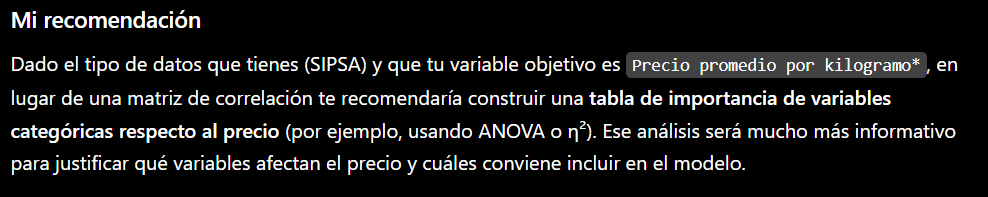

In [53]:
target = "Precio promedio por kilogramo*"
variables_categoricas = [
    "Grupo",
    "Producto",
    "Departamento",
    "Municipio",
    "Mercado",
    "Año",
    "Mes"
]
def eta_squared(df, categoria, objetivo):
    datos = df[[categoria, objetivo]].dropna()
    media_total = datos[objetivo].mean()
    # Suma de cuadrados entre grupos
    ss_between = (
        datos.groupby(categoria)[objetivo]
             .apply(lambda x: len(x) * (x.mean() - media_total) ** 2)
             .sum()
    )
    # Suma de cuadrados total
    ss_total = ((datos[objetivo] - media_total) ** 2).sum()
    return ss_between / ss_total if ss_total != 0 else np.nan

resultado = pd.DataFrame({
    "Variable": variables_categoricas,
    "Eta²": [eta_squared(df, v, target) for v in variables_categoricas]
})

resultado = resultado.sort_values("Eta²", ascending=False)

resultado

,Variable,Eta²
1,Producto,0.795363
0,Grupo,0.268877
4,Mercado,0.084617
3,Municipio,0.053456
5,Año,0.049162
2,Departamento,0.033397
6,Mes,0.000116


**Último paso**: Guardar los datos ya analizados, organizados y listos para entrenar un modelo ML